# Quantum mechanics Computation activities

#  NUMERICAL REPRESENTATION OF INFINITE DIMENSIONAL SYSTEMS
###  Ali Fadlallah

Group coursework.

# 1. Introduction
The goal of this practical work is to make a comparison between the finite difference representation with a DVR (Discrete Variable Representation) for three known quantum systems; Particle in a box, Harmonic Oscillator and $H_2^+$ molecule.


# 2. Theory and methods

We consider a  quantum particle of mass m described by the Hilbert space $\mathcal{H} = L^2(\mathbb{R},dx)$ and a Hamiltonian $H =\frac{-\hbar^2}{2m}\frac{d^2}{dx^2}+V(x)$. 

We choose to carry out a spatial truncation by representing the system only on $[0,L] \subset \mathbb{R}$. 

Let $\{x_0, x_1, ..., x_N \}$ be a regular partition of the interval with $x_0=0$ and $x_N=L$. The numerical representation of the system is then based on this partition. The points of the partition are called collocation points.

There are two forms of representation are elaborated below.

## 2.1 Finite difference representation

The finite difference representation is based on the $\left| x \right>$ represention of the states of $\mathcal{H}$. We choose ($\left| x_i \right>)_{i=0,...,N}$ as the basis of the representation. We have then for $\psi \in \mathcal{H}, \left| \psi \right> \simeq  \sum\limits_{i=0}^N \psi_i\left|x_i\right>$ (with $\psi_i =\left<x_i|\psi \right> = \psi \left|x_i\right>)$.

We can represent the states as:

$$
\left| \psi \right>_{FD} = \begin{pmatrix}
\psi_0 \\
. \\
. \\
\psi_N
\end{pmatrix}
$$

For the action of the potential operator $\hat{V}$ on $\psi$ such that $\hat{V} \psi(x) = V(x)\psi(x)$, this induces a diagonal matrix representation for the potential:

$$
\hat{V}_{FD}=\begin{pmatrix}V(x_{0}) &  & 0\\
 & \ddots\\
0 &  & V(x_{N})
\end{pmatrix}
$$

To represent the Kinetic Hamiltonian $H_K = - \frac{-\hbar^2}{2m}\frac{d^2}{dx^2}$, we use second order taylor developmemts. We can represent the final equation for the Finite Difference Repesentation of the Kinetic Hamiltonian as:

$$
- \frac{-\hbar^2}{2m}\frac{d^2\psi}{dx^2}\bigg\rvert_{x=x_i} \simeq - \frac{-\hbar^2}{2m} \frac{\psi_{i+1} + \psi_{i-1}- 2\psi_i}{\Delta x^2}
$$

so that we get the kinetic Hamiltonian in the format: 

$$
H_{K,FD}=-\frac{\hbar^{2}}{2m\Delta x^{2}}\begin{pmatrix}-2 & 1 & 0 &  & 0\\
1 & -2 & 1\\
 & \ddots & \ddots & \ddots\\
 &  & 1 & -2 & 1\\
0 &  & 0 & 1 & -2
\end{pmatrix}
$$


## 2.2 DVR/FBR representations

We consider two basis-dependant representation. The Discrete Variable Representation(DVR) basis where the operators V(x) are diagonal, and the Finite Basis Representation(FB) where the differential operators are diagonal.

The DVR basis $(u_i(x))_{i=0,...,N}$ is composed by functions such that $u_i(x_j) = \delta_{ij}$. The behaviour of $u_i(x)$ is almost the same as that of the Dirac distribution. The FBR basis $(\phi_n)_{n=0,...,N}$ is chosen as being the Fourier transform of the DVR basis.

According to the treated system, a basis choice could provide better results than another one. A choice
relatively universal, that we follow for this practical is given below:

$$
\begin{aligned}
u_j(x) &= \frac{1}{\sqrt{(N+1)L}}\sum\limits_{n=0}^N e^{ik_n(x-x_j)} \\
\phi_n(x) &= \frac{1}{\sqrt{L}} e^{ik_nx}
\end{aligned}
$$

where ${k_n}_{n=0,...,N}$ are the points of the reciprocal lattice of $\{x_0, x_1, ..., x_N \}$.

This choice is rather natural because it consists to choose the FBR basis as constituted by the plane waves of the $\left|\hbar k\right>$ - representation. Here, we have an analytic expression of the representation of the kinetic operator in the DVR basis:

$$
[H_{K,DVR}]_{ij} =  \frac{-\hbar^2}{2m} \begin{cases} 
  \frac{\pi^2((N+1)^2+2)}{3L^2} & \text{if } i=j \\ 
  \frac{(-1)^{j-i} 2 \pi^2}{L^2sin^2((j-i)\pi / (N+1))} & \text{if } i \neq j
  \end{cases} 
$$




## 3. Applications

We first import the necessary packages

In [ ]:
import numpy as np
from math import pi, sin
from numpy import linalg as LA
from matplotlib import pyplot as plt
from scipy.special import hermite, factorial

### 3.1 PARTICLE IN A BOX

We have for x $\in [0,x_{max}]$. The following potential:
$$
V(x) = \begin{cases} 
  +\infty & \text{if } x=0 \\ 
  0 & \text{if } x\in\,]0, x_{max}[\\ 
  +\infty & \text{if } x=x_{max} \\ 
  \end{cases} 
$$

Since we cannot describe the infinite wall well, during the numerical simulation, we will replace infinity with $10^{10}$

#### 3.1.1
we initialize the initial parameters for this system

In [ ]:
# Initial parameters
xmax = 10 # maximal value of x (in atomic unit): [0,xmax]
m = 1 # particle mass (in atomic unit)
Nstep = 30 # number of cells in the partition
DeltaX = xmax/Nstep # x, partition step (in atomic unit)
Xd = np.linspace(0, xmax, num=Nstep+1)
inf = 1e10
w0 = 1
h = 1

In [ ]:
# potential for the particle in a box 
def V_pb(x):
    if x in (0, xmax):   
        return inf
    elif x>0 and x<xmax: 
        return 0

In [ ]:
# plotting the potentiel
plt.plot(Xd, [V_pb(x) for x in Xd])
plt.xlabel("Position [a.u.]")
plt.ylabel("Energy [a.u.]")
plt.title("V(x) for a particle in a box")
plt.show()

we then construct the Hamiltonian using both methods

In [ ]:
# Construct the Hamiltonian using the FBR method
def Hfd(m, xmax, Nstep):
    Hfd = -2.*np.identity(Nstep+1) # the matrix have order equal to Nstep+1
    DeltaX = xmax/Nstep
    for i in range(0, Nstep):
        Hfd[i, i+1] = 1
        Hfd[i+1, i] = 1
    return -1/(2*m*pow(DeltaX, 2))*Hfd
Hfd_0 = Hfd(m, xmax, Nstep)

In [ ]:
# Construct the Hamiltonian using the DVR method
def Hdvr(m, xmax, Nstep):
    Hdvr = np.zeros((Nstep+1, Nstep+1)) # Hdvr must be initialized as a matrix
    DeltaX = xmax/Nstep
    for i in range(0, Nstep+1):
        for j in range(0, Nstep+1):
            if i==j:
                Hdvr[i,i] = pow(pi, 2)*(pow(Nstep + 1, 2) + 2)/(3*pow(xmax, 2)*2*m)
            else:
                Hdvr[i,j] = pow(-1, j-i)*2*pow(pi, 2)/(pow(xmax * sin((j-i)*pi/(Nstep+1)), 2)*2*m)
    return Hdvr
Hdvr_0 = Hdvr(m, xmax, Nstep)

we then add the potential to the hamiltonian

In [ ]:
def create_hamiltonian(V, Hfd_0, Hdvr_0, xmax, Nstep):    
    Xd = np.linspace(0, xmax, num=Nstep+1)
    valV= [V(x) for x in Xd]
    Vmat = np.diag(valV)
    Hfd = Hfd_0 + Vmat
    Hdvr = Hdvr_0 + Vmat
    return Hfd, Hdvr

Now we compute the two approximations of the spectrum: $Sp^{FD}(H)$ and $Sp^{DVR}(H)$

In [ ]:
# Particle in a box
Hfd_pb, Hdvr_pb = create_hamiltonian(V_pb, Hfd_0, Hdvr_0, xmax, Nstep)
   
# FD method
Sp_FD, phi_FD = LA.eigh(Hfd_pb)
phi_FD = phi_FD/np.sqrt(DeltaX)

# DVR method
Sp_DVR, phi_DVR = LA.eigh(Hdvr_pb)
phi_DVR = phi_DVR/np.sqrt(DeltaX)

#### 3.1.2
initializing the theoretical eigenvalues and plotting them with the DVR/FD methods

In [ ]:
# Theoretical values

n = np.array([ i for i in range(1, Nstep+1)])    # energy levels
Sp_th_pb = np.array([pow(pi*i,2)/(2*pow(xmax,2)) for i in n])    #theoretical spectrum


# ploting the 3 eigevalues 
plt.figure(figsize=(8, 3))
plt.plot(n[: -1], Sp_FD[: -2], 'kx',label='$λ^{FD}$')
plt.plot(n[: -1], Sp_DVR[:-2], 'bx',label='$λ^{DVR}$')
plt.plot(n, Sp_th_pb, 'r--',label='$λ^{th}$')

plt.xlabel("Energy level n", size=10)
plt.ylabel("Eigenvalues [a.u.]", size=10)
plt.title("$λ_n^{FD/DVR/th}$ for a particle in a box "+ f"(Nstep={Nstep})")
plt.legend(loc="best", fontsize=8)
plt.grid()
#plt.xticks(n)
plt.show()  

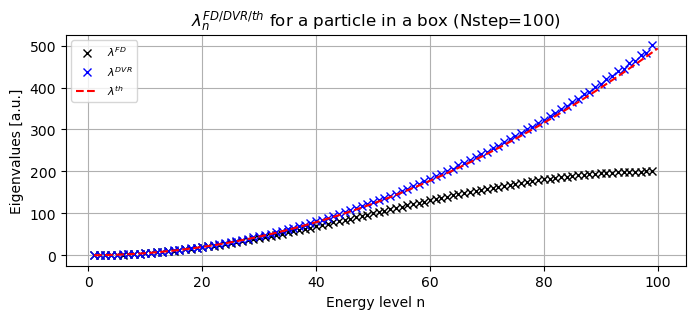

We compute the eigenvalues for the DVR and FD methods and compare them with the theoretical values fro two vaues of Nstep 30 and 100 (computed by changing the initial variable 'Nstep' to 100, then saving the corresponding graph and pasting it as an image).

we can see that both the DVR and the FD method coincide with the theoretical values up untill $n \approx 10$, after which $λ^{FD}$ deviates from the therorical values, while $λ^{DVR}$ stay relatively close to them.<br>
we can say that at low energy $(n\le10)$ levels the two methods agrees with the theoretical values; and at higher energy levels $(n>10)$ the DVR method stays relatively in agreement, while the FD method diverges.<br>
This behaviour is more clearly see with Nstep=100.


We can conclude that the DVR method which uses the fast Fourier tranform algorithm, is not only faster but yields more accurate results than the FD method which uses the Taylor development.

#### 3.1.3
Computing the normalized eigenvectors (by the factor 1/√x) of the numerical Hamiltonians.<br>
already done in 3.1.1 phi_FD and phi_DVR

#### 3.1.4
Drawing the eigenvector for the DVR, FD, and theoretical values for the first 3 energy levels (n = 1, 2, 3)

In [ ]:
# theoretical eigenvector for a partical in a box
phi_th_pb = np.zeros((Nstep+1, Nstep+1))
for j in range(0, Nstep+1):
    for i in range(0, Nstep+1):
        nb = j+1
        phi_th_pb[i,j] = sin(nb*pi*Xd[i]/xmax)*np.sqrt(2/xmax)

        
def plot_wavefct(phi_FD, phi_DVR, phi_th):
    
    # probability density
    FD2 = pow(np.absolute(phi_FD), 2)
    DVR2 = pow(np.absolute(phi_DVR), 2)
    th2 = pow(np.absolute(phi_th), 2)

    
    # ploting the eigenvectors
    for n in (0, 1, 2):
        
        plt.figure(figsize=(12, 5))
        if n == 0 :  phase = 1
        else: phase = -1
        plt.subplot(1, 2, 1)
        plt.plot(Xd, phase*phi_FD[:, n], 'x', label='$\phi^{FD}$')
        plt.plot(Xd, -phase*phi_DVR[:, n], '*', label='$\phi^{DVR}$')
        plt.plot(Xd, phi_th[:, n], '-', label='$\phi^{th}$')
        plt.xlabel("Position [a.u.]", fontsize=8)
        plt.title("$\phi^{FD/DVR/th}$ for a particle in a box"+f" n={n+1} (Nstep={Nstep})", fontsize=10)
        plt.legend(loc="best", fontsize=8)

        plt.subplot(1, 2, 2)
        plt.plot(Xd, FD2[:, n], label='$|\phi^{FD}|^2$')
        plt.plot(Xd, DVR2[:, n], label='$|\phi^{DVR}|^2$')
        plt.plot(Xd, th2[:, n], label='$|\phi^{FD}|^2$')
        plt.xlabel("Position [a.u.]", fontsize=8)
        plt.xlabel("Probability", fontsize=8)
        plt.title(f"Probability density for n={n+1}", fontsize=10)
        plt.legend(loc="best", fontsize=8)
        
        
plot_wavefct(phi_FD, phi_DVR, phi_th_pb)

The graphs above illustrate the eigenvectors $\phi_n^{FD}(x),  \phi_n^{DVR}(x)$ and $\phi_n^{th}(x)$ and their corresponding probability density for n = 1, 2, and 3 respectively. We use the variable phase (equal to -1) to account for the random choice of phase of the programs.


To get the probability of locating a particle at a certain position within the infinite potentiel well we square the wavefunction $\phi_n(x)$. As expected in this system we observe the production of standing waves between [0, xmax]. There is an occurence of nodes and antinodes. the nodes are points were the wavefunction vanishes we can locate those points by locating when the probability density goes to zero at each energy level, the total number of nodes is n+1 (including the boundary conditions). the anti-nodes are where the probability of finding a particle is the highest, it is given by n.

From the above graphs we can see that the eigenvectors overlap for all the plotted orders of n=1, n=2 and n=3 and the values only vary slightly. Thus, the wavefunctions obtained using both the Finite Difference and the DVR methods agrees with high coherence with the theoretically calculated wavefunctions. 

We can conclude that to express a particle in box system, there is no preference to which method we can use at low energy levels, however, for high energy levels we have to use the DVR method.

### 3.2 Harmonic oscillator
The second system that we will treat is a harmonic oscillator with a given potential:

$$
V(x)=\frac{1}{2}k(x-\frac{x_{max}}{2})^{2}
$$

With k = 1 a.u. and $\omega_0 = \sqrt{k/m}$

For the Harmonic oscillator, the initial parameters, the partition vector with the collocation points and the mass are all the same as that of the particle in a box. Thus, we also use the same constructed Numerical Hamiltonians and add the potential of the Harmonic Oscillator to the constructed $H_{FD}$ and $H_{DVR}$ 

In [ ]:
# harmonic oscillator
k = 1
w0 = np.sqrt(k/m)
# potentiel
def V_osc(x):
    return 0.5*k*pow(x - (0.5*xmax), 2)

In [ ]:
# plotting the harmonic oscillator potentiel
plt.plot(Xd, [V_osc(x) for x in Xd])
plt.xlabel("Position [a.u.]")
plt.ylabel("Energy [a.u.]")
plt.title("V(x) for a harmonic oscialltor")
plt.show()

#### 3.2.1
We initialize the hamiltonian and the spectrums using previously defined function since the initial parameters haven't changed.


In [ ]:
# compute the hamiltonian
Hfd_osc, Hdvr_osc = create_hamiltonian(V_osc, Hfd_0, Hdvr_0, xmax, Nstep)

# FD method
Sp_FD, phi_FD = LA.eigh(Hfd_osc)
phi_FD = phi_FD/np.sqrt(DeltaX)

# DVR method
Sp_DVR, phi_DVR = LA.eigh(Hdvr_osc)
phi_DVR = phi_DVR/np.sqrt(DeltaX)

#### 3.2.2
we compute the theoretical spectrum:
$$
Sp^{th}(H)=\{\hbar\omega_{0}(n+\frac{1}{2}), n \in \mathbb{N}\}
$$
and the theoretical wave function:

$$
\phi_n^{th}(x) = \frac{1}{\sqrt{2^nn!}}\left(\frac{m\omega_0}{\pi\hbar}\right)^{1/4}H_n\left(\sqrt{\hbar^{-1}m\omega_0}(x-\frac{x_{max}}{2})\right)e^{-\frac{m\omega_0}{2\hbar}(\frac{x_{max}}{2})^2}
$$

In [ ]:
# theoretical spectrum for a harmonic oscialltor
Sp_th_osc = np.array([n + 0.5 for n in range(Nstep + 1)])

# theoretical wavefunction for a harmonic oscialltor
def Hn(n, x):
    return hermite(n)(x)


phi_th_osc = np.zeros((Nstep+1, 3))
for n in range(3):
    for i in range(0, Nstep+1):
        phi_th_osc[i, n] = 1/np.sqrt((2**n)*factorial(n)) * ((m*w0)/(pi*h))**(1/4)* Hn(n, np.sqrt(m*w0/h)* (Xd[i] - xmax/2))* np.exp(-m*w0/(2*h)*pow(Xd[i] - xmax/2, 2))


Now we will plot the eigenvalues

In [ ]:
# Energy levels
n = np.array([ i for i in range(0, Nstep+1)])

# ploting the 3 eigevalues 
plt.figure(figsize=(8, 3))
plt.plot(n, Sp_FD, 'bx', label='$λ^{FD}$')
plt.plot(n, Sp_DVR, 'kx', label='$λ^{DVR}$')
plt.plot(n, Sp_th_osc, 'r--' ,label='$λ^{th}$')

plt.xlabel("Energy level n", size=10)
plt.ylabel("Eigenvalues [a.u.]", size=10)
plt.title("$λ_n^{FD/DVR/th}$ for a Harmonic Oscillator "+ f"(Nstep={Nstep})")
plt.legend(loc="best", fontsize=8)
#plt.xticks(n)
plt.grid()
plt.show()

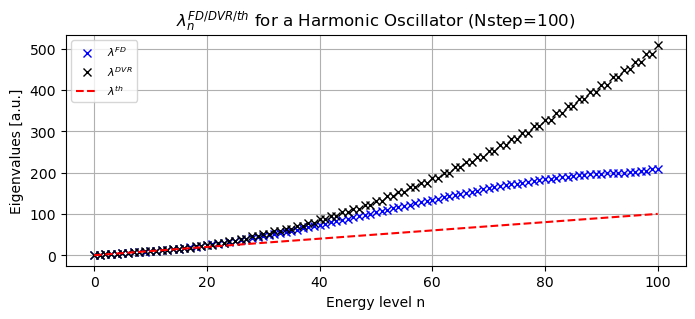

We compute the eigenvalues for the DVR and FD methods and compare them with the theoretical values, for Nstep=30, Nstep=100 (computed by changing the initial variable 'Nstep' to 100, then saving the corresponding graph and pasting it as an image).

for Nstep=30, we can see that both the DVR and the FD method coincide with the theoretical values up untill $n \approx 9$, after which $λ^{DVR}$ deviates from the therorical values, while $λ^{FD}$ stay relatively close to them.<br>
we can say that at low energy levels $(n\le9)$ the two methods agrees with the theoretical values; and for higher energy levels $(n>9)$ the two methods diverges at different rates. This is more apparent when we look at the Nstep=100 graph, where for $n\ge20$ the behavior the FD method is clearly diverging altho not as much as the DVR method which seems to exponentially diverging.<br>

We can conclude that for low energy levels the 2 methods are in agreement with the theoretical approach and can be used to express the system. However, for higher energy levels, both methods heavily diverges, but if one has to choose between these 2 only, it is better to use the FD method, since it's rate of diverging is a lot less than the DVR method.

#### 3.2.3
already done in 3.2.1
phi_FD and phi_DVR

#### 3.2.4
computing and plotting the wavefucntions and their corresponding probability density 

In [ ]:
# probability density
FD2 = pow(np.absolute(phi_FD), 2)
DVR2 = pow(np.absolute(phi_DVR), 2)
th2 = pow(np.absolute(phi_th_osc), 2)

# ploting the eigenvectors
for n in (0, 1, 2):
    plt.figure(figsize=(12, 5))
    if n == 0 or n==1: 
        phase = -1
    else:
        phase = 1
    plt.plot(Xd, -phase*phi_FD[:, n], 'x', label='$\phi^{FD}$')
    plt.plot(Xd, -phase*phi_DVR[:, n], '*', label='$\phi^{DVR}$')
    plt.plot(Xd, phi_th_osc[:, n], '-', label='$\phi^{th}$')
    #plt.plot(Xd, [V_osc(x) for x in Xd], '-', label='$V$')

    plt.xlabel("Position [a.u.]", fontsize=8)
    plt.ylabel("Amplitude [a.u.]", fontsize=8)
    plt.title("$\phi^{FD/DVR/th}$ for a harmonic oscillator"+f" n={n} (Nstep={Nstep})", fontsize=10)
    
    plt.legend(loc="best", fontsize=8)
    plt.show()

$\phi^{FD}$, $\phi^{DVR}$ and $\phi^{th}$ for low energy levels (n = 1, 2, 3) are shown above. we can see that as the value of the n increases, the solutions alternate between even functions and odd functions about $x=\frac{xmax}{2}=5 \: a.u.$ .

We can see that the eigenvectors overlap for all the plotted energy leveles of n=1, 2 and 3. Thus, the wavefunctions obtained using both the Finite Difference and the DVR methods agrees with high coherence with the theoretically calculated wavefunctions. which renforce what we saw earlier, where the DVR/FD spectrums were also in agreement with the theoretical spectrum at low energy levels.

### 3.3 $H_2^+$ molecule
We will consider the molecular ion $H_2^+$ in the bound electronic state $ {}^{2}\!\sum_{+}^{g} $ viewed only from the point of view of its vibrational states.
The data will be changed from the previous systems we studied
$ xmax = 15\:a.u. $, $ m = 911.489\:a.u. $ and $ Nstep = 50 $.

The poteetiel of this system is

$$
V(x) = V_0(e^{-2a(x-x_0)} - 2e^{-a(x-x_0)})
$$

with $ V_0 = 0.10262\:a.u. $, $a = 0.72\:a.u.$ and $x_0 = 2\:a.u.$ 


Initialize the new parameters

#### 3.3.i
To compare the potentiel V(x) to a consistent harmonic oscillator potential we will do a Taylor series expansion around $x_0$.

we get at the $2^{nd}$ order:

$$
V(x) = a^2V_0(x-x_0)^2 - V_0 + \mathcal{O}(x^3)
$$

$3^{rd}$ order:

$$
V(x) = V_0\left(-a^3(x-x_0)^3 +a^2(x-x_0)^2 -1\right) + \mathcal{O}(x^4)
$$

we can see that the $2^{nd}$ expansion is propotional to consistent harmonic oscillator potentiel 
$$V(x) = \frac{1}{2}K(x - x_0)^2 + C$$

with $ \frac{1}{2}K = a^2V_0 $ and $ C=-V_0 $

we first initialize the new parameters

In [ ]:
# new parameters
xmax = 15
m = 911.489
Nstep = 50
DeltaX = xmax/Nstep
Xd = np.linspace(0, xmax, num=Nstep+1)

k=1
h=1
w0 = np.sqrt(k/m)
n = np.arange(1, Nstep+2)

In [ ]:
# new parameters
v0 = 0.10262
a = 0.72
x0 = 2


# H2+ molecule potentiel
def V_H2(x):
    return v0*(np.exp(-2*a*(x-x0))-2*np.exp(-a*(x-x0)))

# 2nd order taylor potentiel
def V_2nd(x):
    return v0*(a**2)*pow(x - x0, 2) - v0

# 3rd order taylor potentiel    
def V_3rd(x):
    return v0*(-(a**3)*pow(x - x0, 3) + (a**2)*pow(x - x0, 2) - 1)

we will plot V(x) againt the $2^{nd}$ and $3^{rd}$ order taylor expansions

In [ ]:
# plotting the potentiels

plt.plot(Xd, [V_H2(x) for x in Xd], label="Exact potentiel")
plt.plot(Xd, [V_2nd(x) for x in Xd], label="$2^{nd}$ order Taylor")
#plt.plot(Xd, [V_3rd(x) for x in Xd], label="$3^{rd}$ order Taylor")
plt.xlim([0,6])
#plt.ylim([-0.105, 0.2])
plt.ylim([-0.105, -0.0])
plt.xlabel("position [a.u.]")
plt.ylabel("energy [a.u.]")
plt.title("V(x) for $H_2^+$ ")

plt.legend(loc="best", fontsize=8)
plt.show()

In the above graph we can see the exact potential of the $H_2^+$ molecule compared to its $2^{nd}$ Taylor expansions. Where the $2^{nd}$ order expansions resemble a consistent harmonic oscillator potentiel.
We can see that for low energy $\lesssim -0.08 \:   a.u.$ (close to $V_0$) and about $x_0 = 2 \:a.u.$ the behavior of the exact potential is similar to that of a consistent harmonic oscillator potentiel modeled using the $2^{nd}$ order taylor expansion of the exact potentiel
$$
V(x) = a^2V_0(x-x_0)^2 - V_0
$$

For higher energies, the exact potential quickly diverges from the consistent harmonic potentiel. Thus, for low energies, it is possible to model the $H_2^+$ molecule after an ahrmonic oscillator, while for higher energies we need another approach.  


#### 3.3.ii.1
initialize the new hamiltonians using the previously defined functions

In [ ]:
# new hamiltonians
Hfd_0 = Hfd(m, xmax, Nstep)
Hdvr_0 = Hdvr(m, xmax, Nstep)

adding the potentiel

In [ ]:
Hfd_H2, Hdvr_H2 = create_hamiltonian(V_H2, Hfd_0, Hdvr_0, xmax, Nstep)

computing the spectrums and wavefunctions

In [ ]:
# FD method
Sp_FD, phi_FD = LA.eigh(Hfd_H2)
phi_FD = phi_FD/np.sqrt(DeltaX)

#DVR method
Sp_DVR, phi_DVR = LA.eigh(Hdvr_H2)
phi_DVR = phi_DVR/np.sqrt(DeltaX)

#### 3.3.ii.2
initialize the exprerimental spectrum

In [ ]:
# accurate computation of the H2+ eigenvalues spectrums
Sp_th_H2 = np.array([-9.731, -8.711, -7.748, -6.841,
            -5.991, -5.195, -4.459, -3.778,
            -3.153, -2.585, -2.073, -1.618,
            -1.218, -0.876, -0.590, -0.360,
            -0.187, -0.070, -0.062]) * 1e-2

plotting the DVR, FD and the experiemntal spectrums

In [ ]:
# plotting the spectrums
plt.figure(figsize=(12, 5))
plt.plot(n[:19], Sp_FD[:19], 'bx', label="$λ^{FD}$")
plt.plot(n[:19], Sp_DVR[:19], 'kx', label="$λ^{DVR}$")
#plt.plot(n[:], Sp_FD, 'bx', label="$λ^{FD}$")
#plt.plot(n, Sp_DVR, 'kx', label="$λ^{DVR}$")
plt.plot(n[:19], Sp_th_H2, 'r--', label="$λ^{th}$")
plt.ylim([-0.1, 0.01])

plt.xticks(n[:19])
plt.xlabel("Energy level n", size=10)
plt.ylabel("Energy [a.u.]", size=10)
plt.title("$λ_n^{FD/DVR/exp}$ for a $H_2^+$ molecule "+ f"(Nstep={Nstep})", size=10)

plt.grid()
plt.legend(loc="best")
plt.show()

In the above graph we plot, for Nstep=50, the eigenvalues calculated using the DVR and FD methods with the theoretical spectrum.

we only show the first 19 levels since we only have 19 values for the theoretical spectrum.

we can see that $λ_n^{DVR}$ is in almost full agreement with $λ_n^{exp}$, while $λ_n^{FD}$ is slightly less accurate. However, when we increase Nstep to 200, both $λ_n^{FD}$ and $λ_n^{DVR}$ becomes in full agreement with the theoretical spectrum. as evident in the below graph.


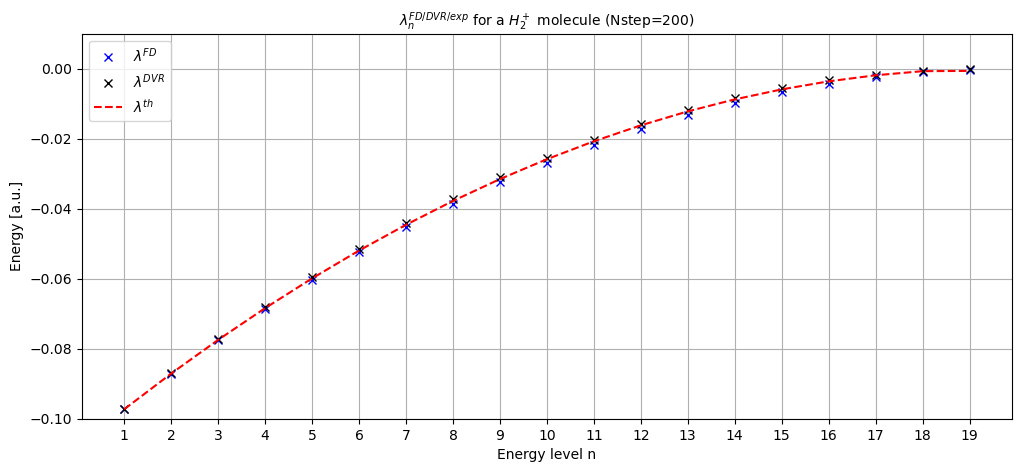
(this graph is computed by changing the variable Nstep to 200 then runing the code and saving the graph as an image)

#### 3.3.ii.3
computing the eigenvectors. (done in 3.3.ii.1)

#### 3.3.ii.4
Since we don't have the theoretical eigenvectors, we will only compare the wavefunctions of the two methods $\phi_n^{FD}(x)$ and $\phi_n^{DVR}(x)$.


In [ ]:
# ploting the 2 spectrums for the first 3 energy level n = 1, 2 and 3

for n in (0, 1, 2):
    plt.figure(figsize=(6, 2))

    plt.plot(Xd, -phi_FD[:, n], label="$\phi^{FD}$")
    plt.plot(Xd, phi_DVR[:, n], '-', label="$\phi^{DVR}$") # multiple by -1 to account for the random phase chossen by the code 

    plt.xlabel("Position [a.u.]", size=8)
    plt.ylabel("Amplitude [a.u.]", size=8)
    plt.title("$\phi^{FD/DVR}(x)$ for a $H_2^+$ molecule" + f" n={n} (Nstep={Nstep})")

    plt.legend(loc="best", fontsize=8)
    plt.show()

the above graphs illustrate the wavefunctions computed using the FD and DVR methods.
if we increase Nstep to 200 we will get smoother graphs (by running the code and saving the graphs as images).

we can see that the wavefunctions are only apparent around $x_0 = 2 \:a.u.$

we can see the similarity between the wavefunctions for the $H_2^+$ molecule and the harmonic oscillator previously computed in 3.2 (graphs below). This is expected since we are showing the low energy levels (the first 3) and we already showed that for low energy levels and around $x_0$ the $H_2^+$ molecule potentiel behave just like an harmonic oscillator. Thus, as it was the case for low energy in the harmonic oscillator, the Finite Difference and the DVR methods are accurate representation of the system. 


Below we show the graphs of the wavefunctions for $H_2^+$ and the harmonic oscillator for n = 0, 1 and 2.

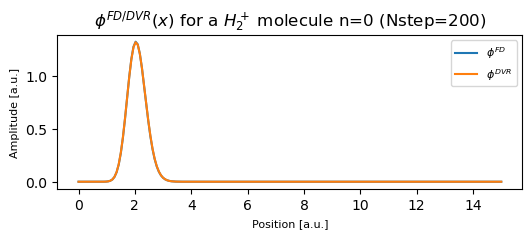 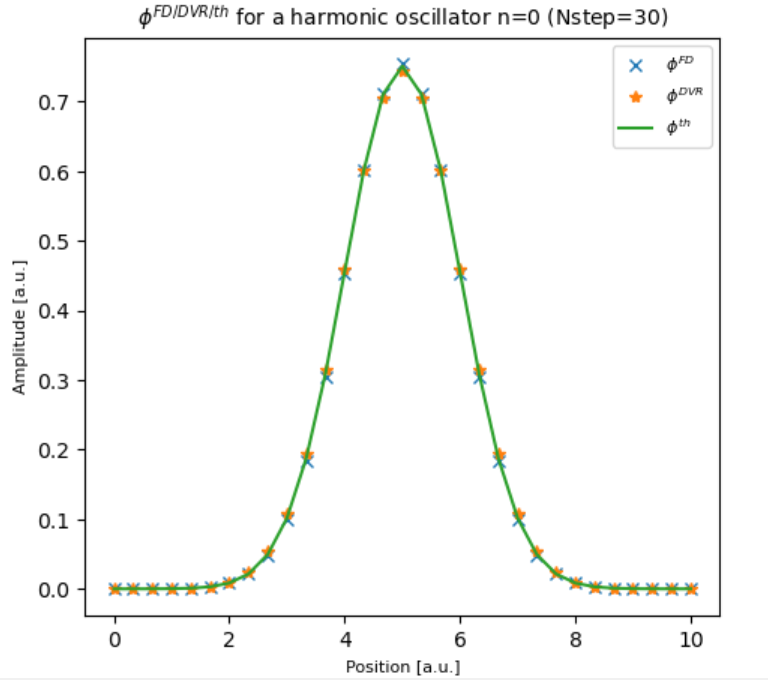
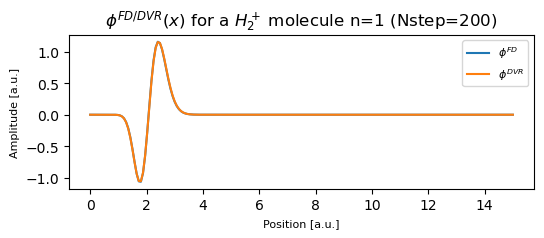 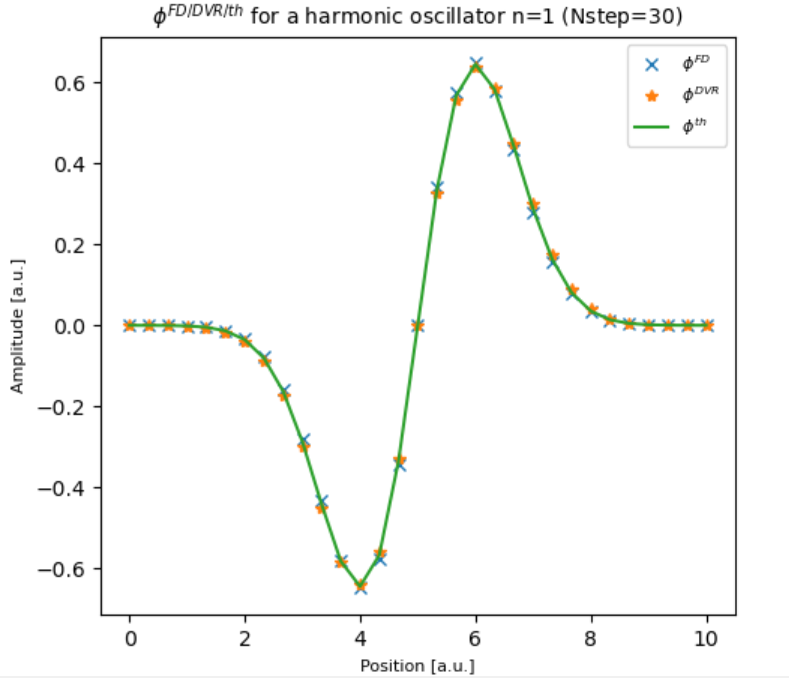
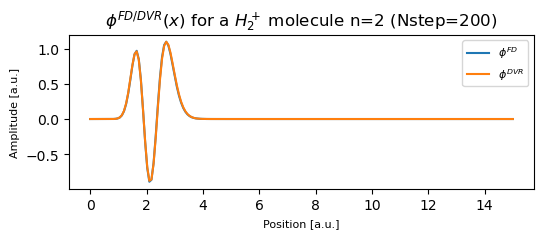 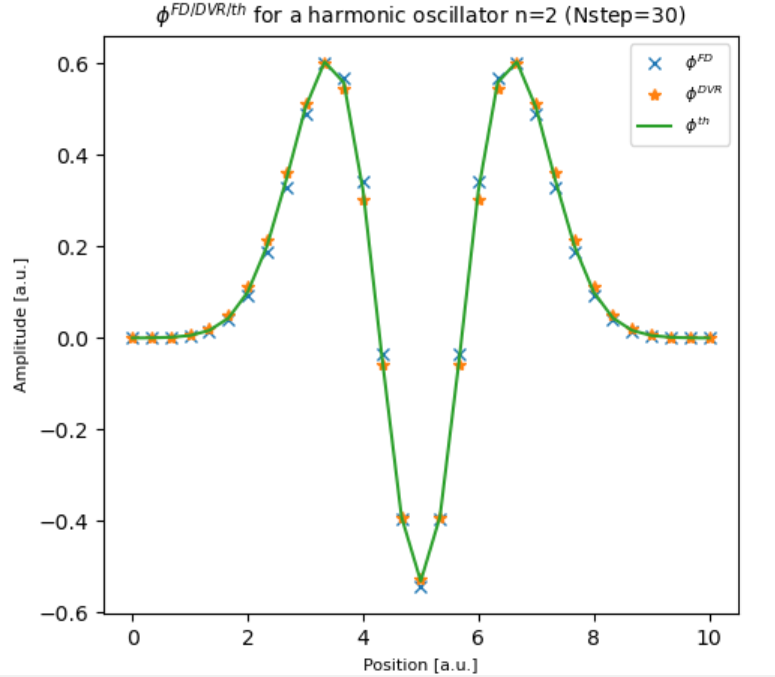

### 3.3.iii Numerical computation of the spectrum

H is numerically represented by an order N+1 matrix. The wave number k and the spatial coordinate x being
related by Fourier transform, the spatial discretisation induces a cut-off of the wave numbers $ \left[-\frac{1}{2\Delta x},\: \frac{1}{2\Delta x}\right] $. Moreover, the spatial cut-off induces a lost of resolution for the wave numbers. We cannot distinguish two
wave numbers with a gap lower than $\Delta k = \frac{1}{L} $. This induces for the spectrum the following properties:

* a) The numerical spectrum presents a spectral cut-off $\left[-\frac{\hbar^2}{8m\Delta x^2},\: \frac{\hbar^2}{8m\Delta x^2}\right]$. It needs then that the discretisation
step $\Delta x$ be sufficiently thin to not lose the low energy spectrum. For all space discretisation step, the very high energy spectrum is
lost.

* b) The numerical representation of the Hamiltonian being a (N + 1)-order matrix, the sum of the eigenvalue
multiplicities is necessarily N + 1. If it exists less of N + 1 eigenvalues in the spectral window $\left[-\frac{\hbar^2}{8m\Delta x^2},\: \frac{\hbar^2}{8m\Delta x^2}\right]$ then artefacts appear (a false zero eigenvalue or an artificial increase of the degeneracy
of the zero eigenvalue).

* c) The numerical spectrum presents a spectral resolution with accuracy $\Delta \lambda = \frac{\hbar\sqrt{2}}{\sqrt{m}L}\sqrt{|\lambda|}$. Two
spectral values with gap lower than $\Delta\lambda$ are not numerically distinguishable. The continuum spectrum is discretised (it is replaced by a sequence of discrete values spaced by $\Delta\lambda$). The
space cut-off must be chosen sufficiently far so the values representing the continuum be sufficiently close to each other, in order for $Sp_
{cont}(H)$ to be indistinguishable of $Sp_
{pp}(H)$. We note that $\Delta\lambda$ increases
with |λ|, the spectral resolution is then more poor at the boundaries of the spectrum.

The continuous spectrum being discretised, the associated states have a numerical behaviour similar to
bound states, they do not have scattering. This is an artefact of the space cut-offs. These ones are indeed
similar to infinite wall potentials at 0 and L. The propagative waves associated with the continuum states are
then reflected by these walls. The reflected waves interfere with the propagative ones, producing stationary
waves associated with the discretised continuum spectrum.


We will study the numerical representation of continuous spectrum and its properties for the two methods (finite differences and DVR) with respect to xmax and Nstep.

First we have to define some functions: <br>
**calculate_spectrum(xmax, Nstep)** returns 2 spectrums calculated using the FD aand DVR methods, it utilize the same steps we already did in 3.3.ii.1 & 3.3.ii.2.<br>
**def plot_sp(xmax, Nstep, limit=False, experimental=False)** plots the spectrums, with the option to show the experimental spectrum, and the spectral range (useful in part a).<br>
**def plot_resolution(xmax, Nstep)** calculates and plotes the resolution $\Delta\lambda$.<br>

In [ ]:
def calculate_spectrum(xmax, Nstep):    
    
    m = 911.489
    
    # initialize the Hamiltonian with the new variables
    Hfd_0 = Hfd(m, xmax, Nstep)
    Hdvr_0 = Hdvr(m, xmax, Nstep)

    #adding the H2 potentiel
    Hfd_H2, Hdvr_H2 = create_hamiltonian(V_H2, Hfd_0, Hdvr_0, xmax, Nstep)

    # computing the spectrums
    # FD method
    Sp_FD = LA.eigvalsh(Hfd_H2)
    Sp_FD = np.sort(Sp_FD)

    #DVR method
    Sp_DVR = LA.eigvalsh(Hdvr_H2)
    Sp_DVR = np.sort(Sp_DVR)
    
    return Sp_FD, Sp_DVR

def plot_resolution(xmax, Nstep):
    
    m = 911.489
    #DeltaX = xmax/Nstep
    n = np.arange(1, Nstep+2)
    
    Sp_FD, Sp_DVR = calculate_spectrum(xmax, Nstep)
    
    # compute delta lambda for the 2 spectrums
    # hbar = 1 a.u.

    delta_lambda_FD  = [np.sqrt(2*abs(lamda)/m)/xmax for lamda in Sp_FD]
    delta_lambda_DVR = [np.sqrt(2*abs(lamda)/m)/xmax for lamda in Sp_DVR]
    
    # plot
    plt.plot(n, delta_lambda_FD, 'bx', label="$\Delta λ^{FD}$")
    plt.plot(n, delta_lambda_DVR, 'rx', label="$\Delta λ^{DVR}$")
    
    
    plt.xlabel("Energy level n", size=10)
    plt.ylabel("Energy [a.u.]", size=10)
    plt.title("$\Delta λ_n^{FD/DVR}$ for a $H_2^+$ molecule $\Delta x = $"+ f"{round(xmax/Nstep, 3)}, xmax = {xmax} a.u.", size=10)
   
    plt.grid()
    plt.legend(loc="best")
    plt.show()
    plt.show()

    return None

    
def plot_eigv_zero(xmax, Nstep, l):
    ''' l is the number of energy levels that appears in sapce cut-off'''
    m = 911.489
    DeltaX = xmax/Nstep
    n = np.arange(1, Nstep+2)

    # spectral cut-off (hbar = 1)
    range = 1/(8*m*DeltaX**2) 
    
    
    Sp_FD, Sp_DVR = calculate_spectrum(xmax, Nstep)
    
   
     # plotting the spectrums
    
    plt.figure(figsize=(5, 2))
    plt.plot(n, Sp_FD, 'bx', label="$λ^{FD}$")
    plt.plot(n, Sp_DVR, 'rx', label="$λ^{DVR}$")

    plt.xlabel("Energy level n", size=10)
    plt.ylabel("Energy [a.u.]", size=10)
    plt.title("$λ_n^{FD/DVR}$ for a $H_2^+$ molecule $\Delta x = $"+ f"{round(xmax/Nstep, 3)}", size=10)

    plt.xlim([0 , l])  
    plt.ylim([-0.05 , 0.05])
    
    plt.grid()
    plt.legend(loc="best")
    plt.show()
    
    return None
    
    
def plot_sp(xmax, Nstep, limit=False, experimental=False):
    '''
    limit: True if we want to limit the y_axis to the spectral range
    experimental: if we want to plot the experimental spectrum
    
    '''
    m = 911.489
    DeltaX = xmax/Nstep
    n = np.arange(1, Nstep+2)

    # spectral cut-off (hbar = 1)
    range = 1/(8*m*DeltaX*DeltaX) 
    
    
    
    Sp_FD, Sp_DVR = calculate_spectrum(xmax, Nstep)

    
    # plotting the spectrums
    
    plt.figure(figsize=(5, 2))
    plt.plot(n, Sp_FD, 'bx', label="$λ^{FD}$")
    plt.plot(n, Sp_DVR, 'rx', label="$λ^{DVR}$")

    
    
    # plotting the spectrums    
    if experimental is True:
        
        Sp_th_H2 = np.array([-9.731, -8.711, -7.748, -6.841,
            -5.991, -5.195, -4.459, -3.778,
            -3.153, -2.585, -2.073, -1.618,
            -1.218, -0.876, -0.590, -0.360,
            -0.187, -0.070, -0.062]) * 1e-2
        
        
        plt.plot(n[:19], Sp_th_H2, 'r--', label="$λ^{pp}$")
        
        plt.xlim([0, 20])
        plt.ylim([min(Sp_th_H2)*1.1, max(Sp_th_H2)*1.1])
        plt.xticks(n[:19]) 
        
    if limit is True:
        
        # spectral cut-off (hbar = 1)
        range = 1/(8*m*DeltaX*DeltaX) 
        
        plt.xticks(np.arange(0, Nstep + 10, 10))
        plt.ylim([-1.05*range , 1.05*range])
   
        if Nstep < 150:
            plt.xlim([0, 0.5*Nstep])
        elif Nstep < 250 :
            plt.xlim([0, 0.33*Nstep])
        elif Nstep < 450:
            plt.xlim([0, 0.25*Nstep])

    plt.xlabel("Energy level n", size=10)
    plt.ylabel("Energy [a.u.]", size=10)
    plt.title("$λ_n^{FD/DVR}$ for a $H_2^+$ molecule $\Delta x = $"+ f"{round(xmax/Nstep, 3)}", size=10)

    plt.grid()
    plt.legend(loc="best")
    plt.show()

Now we will plot the FD/ DVR spectrums while changing Nstep

In [ ]:
# Comparing the Spectrums for different Nstep with the same xmax = 15   
plot_sp(15, 50)
for N in range(200, 450, 100):
    plot_sp(15, N)

The above graphs show the change in $λ_n^{FD}$ and $λ_n^{DVR}$ for xmax = 15 a.u. and increasing Nstep.


We can see that at low energy the both the FD and DVR methods converges and we will zoom in to see exactly how they behave compared to pure points spectrum.
For high energy both the FD and DVR methods diverges.

When we increase Nstep, $\Delta x$ decreases and the spectral cut-off range increase. 
We can also see that for all space discretisation step we chose, the very high energy spectrum is always lost (more on this when we study the properties below).

In [ ]:
# compare the spectrums with the pure points spectrum for xmax= 15 a.u. (fix) and varying Nstep
for N in range(20, 150, 20):
    plot_sp(15, N, experimental = True)

The above graphs show the change in $λ_n^{FD}$, $λ_n^{DVR}$ and $λ_n^{PP}$ for xmax = 15 a.u. and increasing Nstep.

We can see that as Nstep increases, both methods convergees to the pure points spectrum, however, the DVR methods appears to be faster at converging.

Now we are interested in studying the spectrum properties

a) We will study the effect of changing $\Delta x$, to do this we will compute the spectral cut-off
$$
\left[-\frac{\hbar^2}{8m\Delta x^2},\: \frac{\hbar^2}{8m\Delta x^2}\right]
$$  
and we will plot $λ_n^{FD}$ and $λ_n^{DVR}$ in this spectral range.

we will use the **plot_sp(xmax, Nstep, limit=True, experimental=False)** function with limit set to True, and we want to check whether we are losing the low energy spectrum.

In [ ]:
# Comparing the Spectrums for different Nstep with the same xmax = 15
# only showing the spectral range
for N in range(100, 450, 100):
    plot_sp(15, N, limit=True)

The above graphs shows the behavior of $λ_n^{FD}$ compared to $λ_n^{DVR}$ for different Nsteps while fixing xmax at 15 a.u., where We only show the spectral-cut-off range.

we are looking for a value of $\Delta x$ for which we don't lose the low energy specrtum (n = 0, 1, 2, ..).

We can see from those graphs that as Nstep increases, the spectral-cutoff range expands and more enegy levels appears in this cut-off, escpacially the lower energy. and for $\Delta x = 0.037$ (Nstep = 400), all the low energy spectrums (starting from n=0) are included in the spectral range, and this space cut-off contains enregy levels spread from $n=0$ to $n \approx 70$.

Thus, $\Delta x = 0.037$ is sufficiently thin in order to not lose the low energy spectrum.<br>
We already saw when we ploted the full spectrums, that the high energy levels exponentialy diverges and are lost. 

b) In this part we suscpect that, if the space cut-off doesn't include N+1 eigenvalues, then artefacts will appear (a false zero eigenvalue or an artificial increase of the degeneracy of the zero eigenvalue).  
We just saw that for $\Delta x = 0.037$ the space cut-off includes the low energy spectrum, however it only include 70 energy levels where N = 400.<br>
To confirm the previous statement, we will plot the spectrums inside the space cut-off and around zero.<br>
we will use **plot_eigv_zero(xmax=15, Nstep=400, n=70)**


In [ ]:
# plot zero eigenvalues in a space cut-off
plot_eigv_zero(xmax=15, Nstep=400, l=70)

we can see a concentration of zero eigenvalues. 

c) In this part we are interested in studying the effect of changing xmax on the spectral resolution.<br>
To do this, we will plot the resolution $\Delta\lambda$ with respect to the energy level n.<br>
We will use the **plot_resolution(xmax, Nstep)** function

In [ ]:
# plot the resolution
for xmax in range(1, 100, 30):
    plot_resolution(xmax, Nstep = 100)

The above graphs show the change in the spectrum resolution as xmax increases and for Ntsep=100.<br>
We can see that as xmax increases, the overall resolution of spectrum increases except at the boundaries where poorer than the rest of the spectrum. We can see here the tradeoff one must do between xmax and $\Delta x$, since to get better resolution (hence spectrum discretization) we have to increase xmax, but doing so will increase $\Delta x$ which will tighten the spectral range, and possibly exclude the low energy. thus we have to choose a resolution we are comfortable with, and then try to increase Nstep as much as the computation powers allow.


The continuous spectrum being discretised, we are now interested in studying the behavior of the associated states.
We will take (xmax=15, Nstep=400) $\Delta x = 0.037$, since for this value of $\Delta x$ the space cut-off is big enough to include the low energy states. 
we will plot the first high energy level wavefunctions. We expect to get standing waves.
whether for low energy, we already stated that is modeled after a consistent harmonic oscillator. 


In [ ]:
# parameters
m = 911.489
xmax = 15
Nstep = 400
DeltaX = xmax/Nstep
Xd = np.linspace(0, xmax, num=Nstep+1)

# initialize the Hamiltonian with the new variables
Hfd_0 = Hfd(m, xmax, Nstep)
Hdvr_0 = Hdvr(m, xmax, Nstep)

#adding the H2 potentiel
Hfd_H2, Hdvr_H2 = create_hamiltonian(V_H2, Hfd_0, Hdvr_0, xmax, Nstep)

# FD method
phi_FD = LA.eigh(Hfd_H2)[1]
phi_FD = phi_FD/np.sqrt(DeltaX)


print(phi_FD.shape)
#DVR method
phi_DVR = LA.eigh(Hdvr_H2)[1]
phi_DVR = phi_DVR/np.sqrt(DeltaX)


# theoretical eigenvector for a partical in a box
phi_th_pb = np.zeros((Nstep+1, Nstep+1))
for j in range(0, Nstep+1):
    for i in range(0, Nstep+1):
        nb = j+1
        phi_th_pb[i,j] = sin(nb*pi*Xd[i]/xmax)*np.sqrt(2/xmax)

def H2_PotentielBox(n1, n2, step):
    for n in np.arange(n1, n2, step):
        plt.figure(figsize=(10, 4))

        plt.subplot(2, 2, 1)
        plt.plot(Xd, phi_th_pb[:, n], ':', c='green', label='$\phi^{th}$')
        plt.title("$\phi^{FD/th}(x)$ for a $H_2^+$ molecule" + f" n={n} (Nstep={Nstep})", size=9)
        plt.legend(loc="best", fontsize=8)
        
        plt.subplot(2, 2, 2)
        plt.plot(Xd, phi_th_pb[:, n], ':', c='green', label='$\phi^{th}$')
        plt.title("$\phi^{DVR/th}(x)$ for a $H_2^+$ molecule" + f" n={n} (Nstep={Nstep})", size=9)
        plt.legend(loc="best", fontsize=8)
        
        plt.subplot(2, 2, 3)
        plt.plot(Xd, phi_FD[:, n], c='b', label="$\phi^{FD}$")

        plt.xlabel("Position [a.u.]", size=8)
        plt.ylabel("Amplitude [a.u.]", size=8)

        plt.legend(loc="best", fontsize=8)

        plt.subplot(2, 2, 4)
        plt.plot(Xd, phi_DVR[:, n], '-',c ='orange' ,label="$\phi^{DVR}$") # multiple by -1 to account for the random phase chossen by the code 
        plt.xlabel("Position [a.u.]", size=8)
        plt.ylabel("Amplitude [a.u.]", size=8)

        plt.legend(loc="best", fontsize=8)
        plt.show()
H2_PotentielBox(n1=Nstep, n2=Nstep-10, step=-1)

In the above graphs we plot the wavefunctions calculated using the FD/DVR methods with the theoretical wavefunction we used in the particle in a box system (adjusting the parameters). we plot the 10 highest energy level.

We can see that indeed the discretized spectrum behave like a standing wave for high energy levels, when using the DVR method. Based on this, we can conclude that the DVR is more accurate in representing this system. Thus, if we look back at our graphs for $\lambda_n^{FD/DVR}$ as we increase Nstep, $\lambda_n^{FD/DVR}$ was the one diverging at high energy.

In summary, for the $H_2^+$ molecule system can be represented with both methods for low energy, since the low energy levels can be modeled after an harmonic oscillator, which we've already seen to be accurately represented using the 2 methods. However, for high energy levels, the behavior of the discretized spectrum is similar to that of a infinte potential well (particle in a box) where we already saw that for its high energy levels, the DVR method is a very accurate representation.


# 4. Conclusion
Our goal was studying the finite difference (FD) and discrete variable representation (DVR) methods for calculating the kinetic Hamiltonian applied to three systems: particle in a box, harmonic oscillator, and the $H_2^+$ molecule. After setting the initial parameters for each system, the eigenvalues (spectra) and eigenfunctions (wave functions) were computed using the two methods.

#### Particle in a Box
In our analysis of the particle in a box system, we compared the spectra obtained using two different methods, the finite difference (FD) method and the discrete variable representation (DVR) method, to the theoretical spectrum. We found that for low energy levels, both methods agreed with the theoretical values, but for high energy levels, only the DVR method produced accurate results, while the FD method diverged from the theoretical spectrum. We also computed the wave functions for the first 3 energy levels and compared them to the theoretical wave function. As expected for low energy, both methods produced very accurate results. This indicates that the DVR method is more reliable for computing high energy levels in the particle in a box system.

####  Harmonic Oscillator
Similarly for the harmonic oscillator system, we compared the spectra computed using the finite difference (FD) method and the discrete variable representation (DVR) method to the theoretical spectrum. For low energy levels, both methods agreed with the theoretical values. However, for high energy levels, both methods diverged from the theoretical spectrum. This differs from our results for the particle in a box system, where only the DVR method was able to accurately compute high energy levels. We note that the only change we made between the two systems was the potential, with $V_{pb}(x) = 0$ for the particle in a box and $V_{osc}(x) \propto x^2$ for the harmonic oscillator. This suggests that the shape of the potential plays a crucial role in determining the accuracy of the FD and DVR methods at high energy levels. We also computed the wave functions using the two methods and compared them to the theoretical wave function for the first 3 energy levels, and as expected, both methods produced very accurate results for low energy.

#### $H_2^+$ molecule
For the $H_2^+$ molecule system, we first studied the potential of the system and compared it to a harmonic oscillator potential, taken as the second-order Taylor expansion of the exact $H_2^+$ potential. We found that for low energy levels, the dihydrogen cation can be approximated by a harmonic oscillator system.

We then computed the spectra using the two methods, the finite difference (FD) and discrete variable representation (DVR), and compared them with the pure points spectrum. We found that the two methods do converge to the pure points spectrum, however, the DVR method appears to be faster in converging as we decrease the discretization step $\Delta x$.

Next, we studied the numerical computation of the spectrum and found a sufficiently thin $\Delta x$ value ($=0.037$) for which the spectral cut-off range $\left[-\frac{\hbar^2}{8m\Delta x^2},: \frac{\hbar^2}{8m\Delta x^2}\right]$ does not lose the low energy spectrum. We also studied the effect of $x_{max}$ on the overall and boundary resolution of the spectrum and found that as $x_{max}$ increases, the spectrum resolution improves except at the boundaries where it remains poor.

The choice of $x_{max}$ and $\Delta x$ must be carefully considered, since we are interested in choosing a thin discretization step $\Delta x = \frac{x_{max}}{N_{step}}$. We can either decrease $x_{max}$ or increase $N_{step}$, but we have to be careful with $x_{max}$, since decreasing it results in a poor resolution for the discretized spectrum, especially at low energy levels which are very valuable.

Finally, for this system, we studied the high energy levels. After computing a thin enough $\Delta x$, we studied the behavior of the discretized spectrum and compared the high energy level wavefunctions computed using the two methods with that of an infinite well system (same as the particle in a box). We concluded that at high energy, the behavior of the discretized spectrum of the $H_2^+$ is similar to that of a particle in a box and can be represented by the DVR method. Thus, for this system, at low energies both methods are accurate, while for higher energies one should use the DVR method.

In summary, we found that the $H_2^+$ molecule can be approximated by a harmonic oscillator system for low energy levels, and that for these low energy levels the DVR method is faster in converging to the pure points spectrum as the discretization step $\Delta x$ is decreased. We also studied the numerical computation of the spectrum and found a sufficiently thin $\Delta x$ value that does not lose the low energy spectrum. We also found that as $x_{max}$ increases, the spectrum resolution improves except at the boundaries. Finally, we found that the behavior of the $H_2^+$ molecule at high energy levels is similar to that of a particle in a box, and can be accurately represented by the DVR method. 


#### **In conclusion, our study of the finite difference and discrete variable representation methods applied to the particle in a box, harmonic oscillator, and $H_2^+$ molecule systems showed that both methods are effective for calculating the spectra and wave functions of these systems at low energy levels. However, at high energy levels the DVR method was found to be more accurate, particularly in the case of the $H_2^+$ molecule where the choice of $x_{max}$ and $\Delta x$ was crucial for obtaining accurate results. Additionally, we found that the behavior of the $H_2^+$ molecule at high energy levels is similar to that of a particle in a box, and can be accurately represented by the DVR method. These results highlight the importance of choosing the appropriate method and carefully setting the parameters when studying quantum systems.**